In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, BertModel
from sklearn.model_selection import train_test_split
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
    f1_score, accuracy_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
THRESHOLD = 0.73 # previously 0.6, changed when we got rid of dupes from training process

Note, we now read lgbtq dataframe in from matched_lgbtq_bills_with_duplicates.csv (from the updated 03_bills_data_prep_eda.ipynb), rather than matched_lgbtq_bills.csv. That's because the matching method with the ACLU datasets accidentally yielded multiple matches in the legiscan database according to bill_number, year, and state—meaning potentially irrelevant bills were getting drawn in to contaminate our model's training set. Now, we read in matched_lgbtq_bills_with_duplicates.csv before explicitly DROPPING all duplicate rows from this dataframe, allowing us to have an uncontaminated training/testing set.

We then reclassify those dropped rows using our own Legal-BERT model later in this notebook, allowing us to save as a final matched_lgbtq_bills.csv file.

In [5]:
# Positive: your matched LGBTQ+ bills
lgbtq = pd.read_csv('/content/drive/MyDrive/capstone_personal/matched_lgbtq_bills_with_duplicates.csv') # (changed file path slightly)

# Negative: random sample from unmatched LegiScan bills
all_bills = pd.read_csv('/content/drive/MyDrive/capstone_personal/all_bills_2021_2026.csv',
    engine='python', # ishanis edits
    on_bad_lines='skip',) # ishanis edits — added b/c of error below
    # ParserError: Error tokenizing data. C error: Expected 27 fields in line 70638, saw 29

print(f"lgbtq shape: {lgbtq.shape}")
print(f"all_bills shape: {all_bills.shape}")

lgbtq shape: (2332, 45)
all_bills shape: (746423, 27)


In [6]:
all_bills['year'] = pd.to_datetime(all_bills['status_date']).dt.year
all_bills['year'] = all_bills['year'].fillna(all_bills['year']).astype('Int64')

all_bills['text'] = all_bills['title'].fillna('') + '. ' + all_bills['description'].fillna('')

In [7]:
# get bill text (early?)
lgbtq = lgbtq.merge(
    all_bills[['bill_id', 'text']].drop_duplicates(subset='bill_id'),
    on='bill_id',
    how='left'
)

In [9]:
for col in ['year', 'bill_number', 'bill_id', 'state']:
    print(f"{col}: {lgbtq[col].isna().sum()} NaNs")

year: 3 NaNs
bill_number: 0 NaNs
bill_id: 0 NaNs
state: 0 NaNs


In [10]:
print(all_bills['text'].isna().sum())
print(all_bills['text'].dtype)
print(all_bills['text'].head(10).tolist())

0
object
['Audit Of Cares Act Funds. An Act providing for audits of CARES Act funds expended for the community assistance program and direct grants to municipalities and communities.', 'Minimum Age To Sell Tobacco/nicotine. An Act relating to the minimum age of persons allowed to sell cigarettes, cigars, tobacco, electronic smoking products, products containing nicotine, or products containing tobacco.', 'Definition Of "disaster": Cybersecurity. An Act relating to the definition of &#39;disaster.&#39;', 'Business/prof. License Immunity Covid-19. An Act providing immunity from liability and disciplinary action for occupational licensees for exposure of clients to COVID-19; providing immunity from liability for persons engaging in business and their employees for exposure of customers to COVID-19; and providing for an effective date.', 'Sexual Assault; Def. Of "consent". An Act relating to sexual abuse of a minor; relating to sexual assault; relating to the code of military justice; rela

New: removing duplicate rows before training.

In [11]:
# Save copies of original dataframes
lgbtq_original = lgbtq.copy()
all_bills_original = all_bills.copy()

# Isolate duplicate rows in lgbtq (keeping all occurrences)
lgbtq_duplicates = lgbtq[lgbtq.duplicated(subset=['bill_number', 'year', 'state'], keep=False)]

# Remove duplicate rows in lgbtq based on bill_number, year, and state
lgbtq = lgbtq.drop_duplicates(subset=['bill_number', 'year', 'state'])

# Create a set of (bill_number, year, state) tuples from the cleaned lgbtq df
lgbtq_keys = set(zip(lgbtq['bill_number'], lgbtq['year'], lgbtq['state']))

# Remove matching bills from all_bills
mask = ~pd.Series(zip(all_bills['bill_number'], all_bills['year'], all_bills['state'])).isin(lgbtq_keys)
all_bills = all_bills[mask].reset_index(drop=True)

print(f"lgbtq_original shape: {lgbtq_original.shape}")
print(f"lgbtq shape (deduplicated): {lgbtq.shape}")
print(f"lgbtq_duplicates shape: {lgbtq_duplicates.shape}")
print(f"all_bills_original shape: {all_bills_original.shape}")
print(f"all_bills shape (filtered): {all_bills.shape}")

lgbtq_original shape: (2332, 46)
lgbtq shape (deduplicated): (2259, 46)
lgbtq_duplicates shape: (119, 46)
all_bills_original shape: (746423, 29)
all_bills shape (filtered): (744227, 29)


In [12]:
import matplotlib.pyplot as plt

def plot_unique_vs_total(df, title="Unique Bills vs Total Rows by State"):
    state_stats = []
    for state in all_states:
        state_df = df[df['state'] == state]
        total_rows = len(state_df)
        unique_bills = state_df.drop_duplicates(subset=['bill_number', 'year', 'state']).shape[0]
        state_stats.append({'state': state, 'unique_bills': unique_bills, 'total_rows': total_rows})

    stats_df = pd.DataFrame(state_stats)  # all states included, even zeros

    plt.figure(figsize=(12, 7))
    plt.scatter(stats_df['unique_bills'], stats_df['total_rows'], alpha=0.7, edgecolors='black', linewidths=0.5)

    for _, row in stats_df.iterrows():
        plt.annotate(row['state'], (row['unique_bills'], row['total_rows']),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)

    max_val = max(stats_df['unique_bills'].max(), stats_df['total_rows'].max())
    plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='y = x (no duplicates)')

    plt.xlabel("Number of Unique Bills (bill_number, year, state)")
    plt.ylabel("Total Number of Rows")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
all_states = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY", "DC"
]

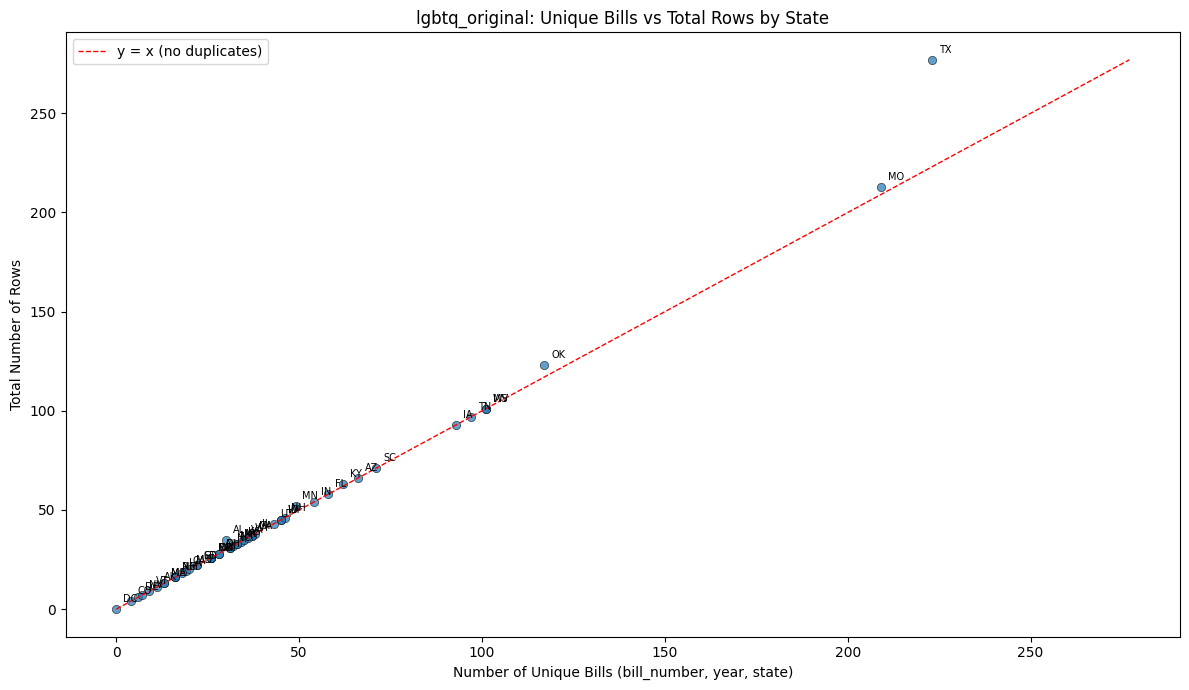

In [14]:
plot_unique_vs_total(lgbtq_original, title="lgbtq_original: Unique Bills vs Total Rows by State")

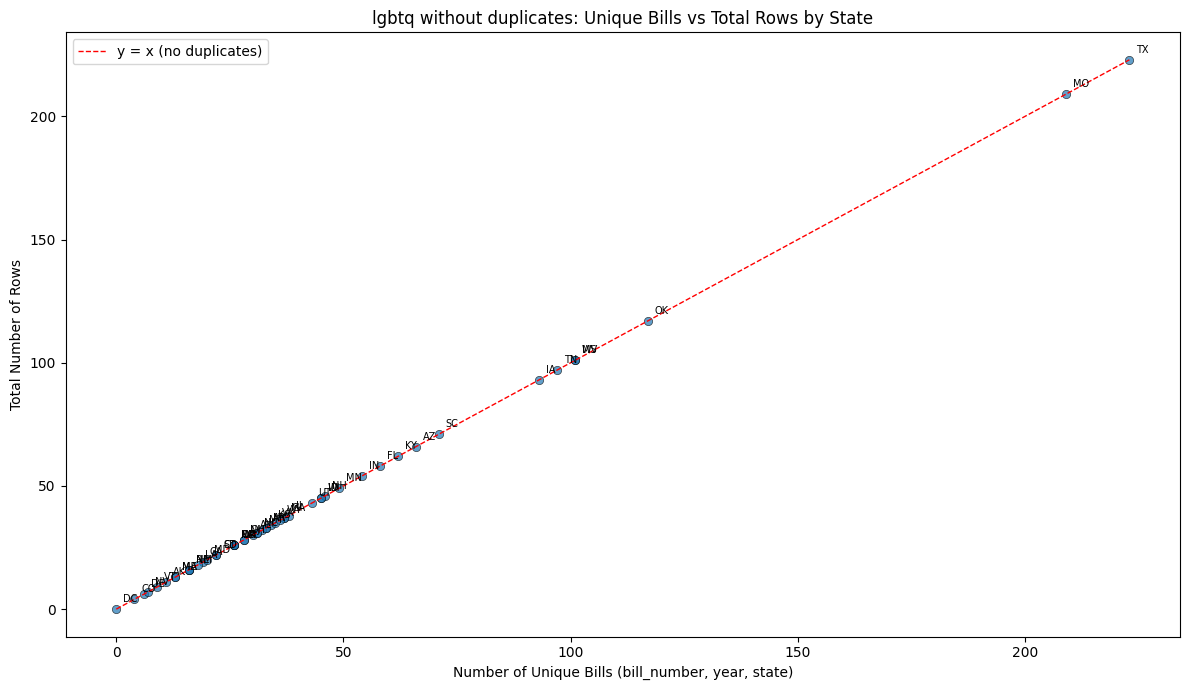

In [15]:
plot_unique_vs_total(lgbtq, title="lgbtq without duplicates: Unique Bills vs Total Rows by State")

Continue as usual.

In [16]:
lgbtq['label_id'] = 1

non_lgbtq = all_bills[~all_bills['bill_id'].isin(lgbtq['bill_id'])].sample(
    n=len(lgbtq) * 2,
    random_state=42
)
non_lgbtq['label_id'] = 0

df = pd.concat([lgbtq, non_lgbtq]).sample(frac=1, random_state=42)

In [17]:
print(df['text'].isna().sum())
print(df['text'].dtype)
print(df['text'].head(10).tolist())

0
object
['Candidates for school board office.. Candidates for school board office. Provides that a candidate for a school board office may not be an employee or agent of that school corporation.', 'A resolution to declare April 28, 2022, as Suits and Sneakers Day in the state of Michigan.. A resolution to declare April 28, 2022, as Suits and Sneakers Day in the state of Michigan.', 'Sororities and fraternities; prohibit IHL Board from requiring to accept persons with gender reassignment.. An Act To Create New Section 37-111-15, Mississippi Code Of 1972, To Prohibit The State Board Of Institutions Of Higher Learning And Any College Or University Under Its Jurisdiction From Requiring Fraternities And Sororities To Accept Any Person Who Has Gender Reassignment Surgery, Gender Transition Or Any Gender Transition Procedures; To Amend Section 37-111-11, Mississippi Code Of 1972, To Conform To The Preceding Section; And For Related Purposes.', 'YOUTH HEALTH PROTECTION ACT. Creates the Youth 

In [18]:
len(df)

6777

In [19]:
# defining

Deriving some meta-data...

In [20]:
def parse_party_counts(party_str):
    """Parse 'R | D | R | R' into party counts."""
    if pd.isna(party_str):
        return {'R': 0, 'D': 0, 'Other': 0}

    parties = [p.strip() for p in str(party_str).split('|')]
    counts = {
        'R': sum(1 for p in parties if p == 'R'),
        'D': sum(1 for p in parties if p == 'D'),
        'Other': sum(1 for p in parties if p not in ('R', 'D'))
    }
    return counts

# Apply and expand into columns
party_counts = df['sponsor_parties'].apply(parse_party_counts).apply(pd.Series)
df['r_sponsors'] = party_counts['R']
df['d_sponsors'] = party_counts['D']
df['other_sponsors'] = party_counts['Other']


# Derive the dominant party for each bill
def dominant_party(row):
    if row['r_sponsors'] > row['d_sponsors']:
        return 'R'
    elif row['d_sponsors'] > row['r_sponsors']:
        return 'D'
    elif row['r_sponsors'] == 0 and row['d_sponsors'] == 0:
        return 'Other'
    else:
        return 'Bipartisan'


df['dominant_party'] = df.apply(dominant_party, axis=1)

In [21]:
# copied code from ambro for state lean

state_year_profiles = df.groupby(['state', 'year']).agg(
    # --- Volume ---
    total_bills=('bill_id', 'count'),

    # --- Partisan Sponsorship ---
    r_sponsored_bills=('dominant_party', lambda x: (x == 'R').sum()),
    d_sponsored_bills=('dominant_party', lambda x: (x == 'D').sum()),
    bipartisan_bills=('dominant_party',
                      lambda x: (x == 'Bipartisan').sum()),

    # --- Pass Rates ---
    # total_passed=('passed', 'sum'),

    # --- Sponsor Counts (avg engagement) ---
    avg_sponsor_count=('sponsor_count', 'mean'),
    avg_action_count=('action_count', 'mean'),
).reset_index()

# --- Derived Ratios ---

# Partisan lean: ratio of R-sponsored to total partisan bills
# Values > 0.5 = R-leaning legislature, < 0.5 = D-leaning
state_year_profiles['partisan_bills'] = (
    state_year_profiles['r_sponsored_bills'] +
    state_year_profiles['d_sponsored_bills']
)
state_year_profiles['state_r_sponsorship_ratio'] = (
    state_year_profiles['r_sponsored_bills'] /
    state_year_profiles['partisan_bills']
).fillna(0.5)  # Handle edge cases

# # Overall pass rate
# state_year_profiles['overall_pass_rate'] = (
#     state_year_profiles['total_passed'] /
#     state_year_profiles['total_bills']
# )

# Bipartisan ratio: what fraction of bills have mixed sponsorship
state_year_profiles['bipartisan_ratio'] = (
    state_year_profiles['bipartisan_bills'] /
    state_year_profiles['total_bills']
)

print("\n--- State-Year Profile Sample ---")
cols = ['state', 'year', 'total_bills', 'state_r_sponsorship_ratio',
        'bipartisan_ratio']
print(state_year_profiles[cols].head(10).to_string(index=False))


--- State-Year Profile Sample ---
state    year  total_bills  state_r_sponsorship_ratio  bipartisan_ratio
   AK  2021.0            2                   0.000000               0.0
   AK  2022.0            4                   0.666667               0.0
   AK  2023.0            5                   1.000000               0.0
   AK  2024.0            3                   1.000000               0.0
   AK  2025.0            2                   1.000000               0.0
   AL  2021.0           16                   0.812500               0.0
   AL  2022.0           13                   0.916667               0.0
   AL  2023.0           12                   1.000000               0.0
   AL  2024.0           14                   0.785714               0.0
   AL  2025.0           22                   0.857143               0.0


In [22]:
state_lean_2024 = (
    state_year_profiles
    .sort_values("year")
    .groupby("state")
    .tail(1)[["state", "year", "state_r_sponsorship_ratio"]]
)

In [23]:
print(state_lean_2024.isna().sum())

state                        0
year                         0
state_r_sponsorship_ratio    0
dtype: int64


In [24]:
state_lean_2024['state_R_leaning'] = state_lean_2024['state_r_sponsorship_ratio'] > 0.5

In [25]:
df = df.merge(
    state_lean_2024[['state', 'state_R_leaning', 'state_r_sponsorship_ratio']],
    on='state',
    how='left'
)

# maybe change later

In [26]:
lgbtq['year'] = lgbtq['session_year']
lgbtq['true_stance'] = lgbtq['label']


In [27]:
df['percent_yea'] = df['total_yea'] / (df['total_yea'] + df['total_nay'])
df['percent_nay'] = df['total_nay'] / (df['total_yea'] + df['total_nay'])

df['percent_yea'] = df['percent_yea'].fillna(0)
df['percent_nay'] = df['percent_nay'].fillna(0)

Defining train and test sets.

In [28]:

print(f"Total bills: {len(df)}")
print(f"  LGBTQ+:     {(df['label_id']==1).sum()}")
print(f"  Non-LGBTQ+: {(df['label_id']==0).sum()}")
print(f"\nSample text:\n{df['text'].iloc[0]}")

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label_id']
)
print(f"\nTrain: {len(train_df)} ({train_df['label_id'].mean():.1%} LGBTQ+)")
print(f"Test:  {len(test_df)} ({test_df['label_id'].mean():.1%} LGBTQ+)")

Total bills: 6777
  LGBTQ+:     2259
  Non-LGBTQ+: 4518

Sample text:
Candidates for school board office.. Candidates for school board office. Provides that a candidate for a school board office may not be an employee or agent of that school corporation.

Train: 5421 (33.3% LGBTQ+)
Test:  1356 (33.3% LGBTQ+)


In [29]:
MODEL_NAME = 'nlpaueb/legal-bert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = BertModel.from_pretrained(MODEL_NAME).to(device)

# Quick sanity check
test_inputs = tokenizer("An act prohibiting gender transition procedures for minors",
                       return_tensors="pt").to(device)
test_outputs = base_model(**test_inputs)
print(f"LegalBERT hidden size: {test_outputs.last_hidden_state.shape}")
# Should be [1, seq_len, 768]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LegalBERT hidden size: torch.Size([1, 10, 768])


In [30]:
# 1. Token length distribution across ALL bills
token_lengths = []
for _, row in df.iterrows():
    text = str(row['text']).strip()
    if text:
        toks = tokenizer(text)['input_ids']
        token_lengths.append(len(toks))

token_lengths = np.array(token_lengths)

print("TOKEN LENGTH DISTRIBUTION")
print("=" * 50)
print(f"  Min:    {token_lengths.min()}")
print(f"  25th:   {np.percentile(token_lengths, 25):.0f}")
print(f"  Median: {np.percentile(token_lengths, 50):.0f}")
print(f"  75th:   {np.percentile(token_lengths, 75):.0f}")
print(f"  95th:   {np.percentile(token_lengths, 95):.0f}")
print(f"  Max:    {token_lengths.max()}")

# How many bills get truncated at each max_len?
for ml in [128, 256, 512]:
    truncated = (token_lengths > ml).sum()
    pct = truncated / len(token_lengths) * 100
    print(f"\n  max_len={ml}: {truncated}/{len(token_lengths)} bills truncated ({pct:.1f}%)")


# 2. Show a few examples: short, median, long
sorted_idx = np.argsort(token_lengths)
examples = {
    'Shortest': sorted_idx[0],
    'Median':   sorted_idx[len(sorted_idx)//2],
    'Longest':  sorted_idx[-1],
}

for name, idx in examples.items():
    row = df.iloc[idx]
    text = str(row['text']).strip()
    toks = tokenizer(text)['input_ids']
    decoded = tokenizer.convert_ids_to_tokens(toks)

    print(f"\n{'='*50}")
    print(f"{name} bill: {row.get('state','')} {row.get('bill_number','')} ({len(toks)} tokens)")
    print(f"Raw: {text[:200]}{'...' if len(text)>200 else ''}")
    print(f"Tokens: {' '.join(decoded[:40])}{'...' if len(decoded)>40 else ''}")

Token indices sequence length is longer than the specified maximum sequence length for this model (729 > 512). Running this sequence through the model will result in indexing errors


TOKEN LENGTH DISTRIBUTION
  Min:    7
  25th:   31
  Median: 50
  75th:   79
  95th:   183
  Max:    9489

  max_len=128: 678/6777 bills truncated (10.0%)

  max_len=256: 177/6777 bills truncated (2.6%)

  max_len=512: 43/6777 bills truncated (0.6%)

Shortest bill: UT HB0096 (7 tokens)
Raw: Fraud Amendments. Fraud Amendments
Tokens: [CLS] fraud amendments . fraud amendments [SEP]

Median bill: MD HB578 (50 tokens)
Raw: Procurement - Department of Transportation and Maryland Transportation Authority Contracts - Board of Public Works Authority. Authorizing the Board of Public Works to control certain procurement contr...
Tokens: [CLS] procurement - department of transportation and maryland transportation authority contracts - board of public works authority . authoriz ##ing the board of public works to control certain procurement contracts by the department of transportation and maryland transportation authority value...

Longest bill: OH HB96 (9489 tokens)
Raw: Make state operating appr

In [31]:
class BillDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data = []
        for _, row in dataframe.iterrows():
            text = str(row['text']).strip()
            if not text:
                continue
            encoded = tokenizer(
                text,
                return_tensors='pt',
                max_length=max_len,
                truncation=True,
                padding='max_length',
            )
            self.data.append({
                'input_ids': encoded['input_ids'].squeeze(0).to(device),
                'attention_mask': encoded['attention_mask'].squeeze(0).to(device),
                'label': torch.tensor(row['label_id'], dtype=torch.float32, device=device),
            })
        print(f"  Loaded {len(self.data)} examples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


MAX_LEN = 256

print("Building train set...")
train_data = BillDataset(train_df, tokenizer, max_len=MAX_LEN)
print("Building test set...")
test_data = BillDataset(test_df, tokenizer, max_len=MAX_LEN)

Building train set...
  Loaded 5421 examples
Building test set...
  Loaded 1356 examples


In [32]:
class LegalBERTClassifier(torch.nn.Module):
    def __init__(self, bert_model, hidden_size=768, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.dropout = torch.nn.Dropout(dropout)
        self.linear = torch.nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask=None):
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state
        cls_output = bert_output[:, 0, :]
        cls_output = self.dropout(cls_output)
        logit = self.linear(cls_output)
        return torch.squeeze(logit)


model = LegalBERTClassifier(base_model).to(device)

# No class weighting needed — 2:1 ratio is mild enough
# loss_fn = torch.nn.BCEWithLogitsLoss()

# new loss_fn
# labels = torch.tensor([ex['label'] for ex in train_data], dtype=torch.float)  # adjust if needed
# n_pos = labels.sum()
# n_neg = labels.numel() - n_pos
# pos_weight = (n_neg / (n_pos + 1e-8)).to(device)   # ~ 97/3 = 32.33
# loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# print("pos_weight =", pos_weight.item())

# claude loss_fn
# Tune this: try 2.5, 3.0, 4.0
# 2.5 best for now (2.0 and 3.0 are objectively, all-around worse)
pos_weight = torch.tensor([3.0]).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)



BATCH_SIZE = 8
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
batch = next(iter(train_loader))
out = model(batch['input_ids'], batch['attention_mask'])
loss = loss_fn(out, batch['label'])
print(f"Sanity check — output: {out.shape}, loss: {loss.item():.4f}")

Sanity check — output: torch.Size([8]), loss: 1.1330


In [33]:
def train_loop(dataloader, model, loss_fn, optimizer, reporting_interval=50):
    model.train()
    epoch_loss, total_batches = 0, 0

    for batch_idx, data in enumerate(dataloader):
        optimizer.zero_grad()
        outputs = model(data['input_ids'], data['attention_mask'])
        loss = loss_fn(outputs, data['label'])
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total_batches += 1

        if (batch_idx + 1) % reporting_interval == 0:
            print(
                f"  Batch {batch_idx + 1}: avg loss = {epoch_loss / total_batches:.4f}")

    print(f"  Train loss: {epoch_loss / max(total_batches, 1):.4f}")


def eval_loop(dataloader, model, loss_fn):
    model.eval()
    test_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for data in dataloader:
            outputs = model(data['input_ids'], data['attention_mask'])
            test_loss += loss_fn(outputs, data['label']).item()

            preds = (torch.sigmoid(outputs) >= THRESHOLD).float()  # replace torch.round(...)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(data['label'].cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(
        f"  Test loss: {test_loss / len(dataloader):.4f}, Accuracy: {100 * accuracy:.1f}%")
    print("\n" + classification_report(
        all_labels, all_preds,
        target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3
    ))

In [34]:
for param in model.bert.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4
)

print("Phase 1: Classifier head only\n")
for epoch in range(3):
    print(f"Epoch {epoch + 1}/3")
    train_loop(train_loader, model, loss_fn, optimizer)
    eval_loop(test_loader, model, loss_fn)
    print()

# Phase 2: Unfreeze last 2 BERT layers
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

print("Phase 2: Fine-tuning last 2 layers\n")
for epoch in range(2):
    print(f"Epoch {epoch + 1}/2")
    train_loop(train_loader, model, loss_fn, optimizer)
    eval_loop(test_loader, model, loss_fn)
    print()

print("Done!")

Phase 1: Classifier head only

Epoch 1/3
  Batch 50: avg loss = 1.0720
  Batch 100: avg loss = 1.0928
  Batch 150: avg loss = 1.1006
  Batch 200: avg loss = 1.1024
  Batch 250: avg loss = 1.0966
  Batch 300: avg loss = 1.0933
  Batch 350: avg loss = 1.0879
  Batch 400: avg loss = 1.0819
  Batch 450: avg loss = 1.0787
  Batch 500: avg loss = 1.0777
  Batch 550: avg loss = 1.0734
  Batch 600: avg loss = 1.0711
  Batch 650: avg loss = 1.0680
  Train loss: 1.0656
  Test loss: 1.0341, Accuracy: 76.3%

              precision    recall  f1-score   support

  non-LGBTQ+      0.783     0.892     0.834       904
      LGBTQ+      0.699     0.504     0.586       452

    accuracy                          0.763      1356
   macro avg      0.741     0.698     0.710      1356
weighted avg      0.755     0.763     0.751      1356


Epoch 2/3
  Batch 50: avg loss = 0.9922
  Batch 100: avg loss = 0.9906
  Batch 150: avg loss = 1.0038
  Batch 200: avg loss = 1.0071
  Batch 250: avg loss = 1.0067
  Batc

In [35]:
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for data in test_loader:
        outputs = model(data['input_ids'], data['attention_mask'])
        # Apply sigmoid to convert logits → probabilities
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(data['label'].cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

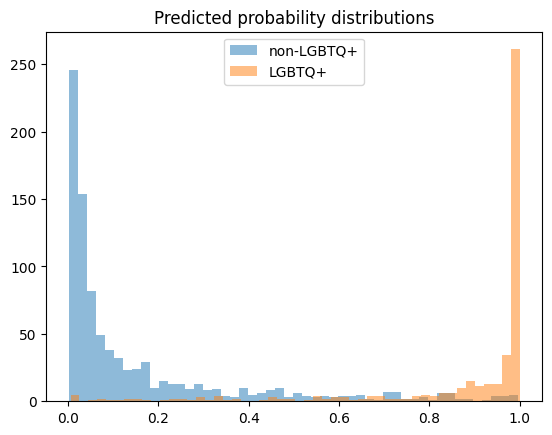

In [36]:
plt.hist(all_probs[all_labels==0], bins=50, alpha=0.5, label='non-LGBTQ+')
plt.hist(all_probs[all_labels==1], bins=50, alpha=0.5, label='LGBTQ+')
plt.legend()
plt.title("Predicted probability distributions")
plt.show()

In [37]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

# F1 at each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best F1 threshold: {best_threshold:.3f}")

# Compare thresholds
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds = (all_probs >= t).astype(int)
    print(f"\nThreshold = {t}:")
    print(classification_report(all_labels, preds,
          target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3))

Best F1 threshold: 0.731

Threshold = 0.3:
              precision    recall  f1-score   support

  non-LGBTQ+      0.969     0.830     0.894       904
      LGBTQ+      0.735     0.947     0.828       452

    accuracy                          0.869      1356
   macro avg      0.852     0.888     0.861      1356
weighted avg      0.891     0.869     0.872      1356


Threshold = 0.4:
              precision    recall  f1-score   support

  non-LGBTQ+      0.961     0.867     0.912       904
      LGBTQ+      0.778     0.929     0.847       452

    accuracy                          0.888      1356
   macro avg      0.869     0.898     0.879      1356
weighted avg      0.900     0.888     0.890      1356


Threshold = 0.5:
              precision    recall  f1-score   support

  non-LGBTQ+      0.953     0.903     0.927       904
      LGBTQ+      0.824     0.912     0.866       452

    accuracy                          0.906      1356
   macro avg      0.889     0.907     0.896      

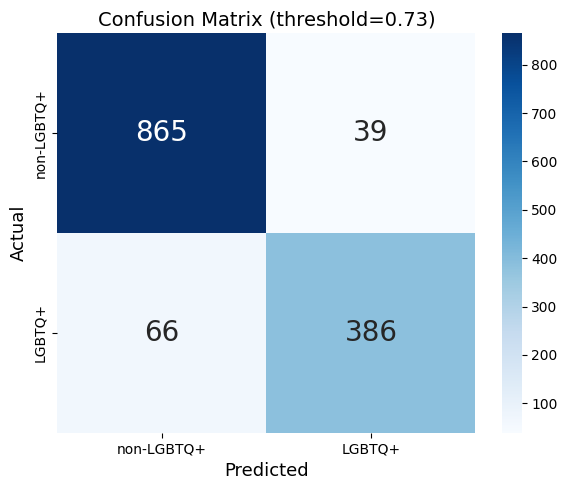

              precision    recall  f1-score   support

  non-LGBTQ+      0.929     0.957     0.943       904
      LGBTQ+      0.908     0.854     0.880       452

    accuracy                          0.923      1356
   macro avg      0.919     0.905     0.912      1356
weighted avg      0.922     0.923     0.922      1356



In [63]:
# 0.6 puts the accuracy > 90% while putting FP rate at ~3.3%. Seems like the right

all_preds = (all_probs >= THRESHOLD).astype(int)

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-LGBTQ+', 'LGBTQ+'],
            yticklabels=['non-LGBTQ+', 'LGBTQ+'],
            annot_kws={'size': 20}, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title(f'Confusion Matrix (threshold={THRESHOLD})', fontsize=14)
plt.tight_layout()
plt.show()

print(classification_report(
    all_labels, all_preds,
    target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3
))

## Checking duplicate rows
These duplicate rows were EXCLUDED from the previous training or the testing sets as the ACLU bills had multiple matches in the legiscan database according to bill_number, year, and state. Now, we will use our own Legal-BERT model to classify them and save as a final matched_lgbtq_bills.csv (rather than the previous matched_lgbtq_bills_with_duplicates.csv)

In [64]:
dup_scored = lgbtq_duplicates

In [65]:
dup_scored.columns

Index(['state', 'bill_id', 'session_id', 'bill_number', 'status',
       'status_desc', 'status_date', 'title', 'description', 'committee_id',
       'committee', 'last_action_date', 'last_action', 'url', 'state_link',
       'sponsor_names', 'sponsor_parties', 'primary_sponsor', 'sponsor_count',
       'action_count', 'last_history_action', 'document_count',
       'document_types', 'document_urls', 'rollcall_count', 'total_yea',
       'total_nay', 'year', 'r_sponsors', 'd_sponsors', 'other_sponsors',
       'bill_dominant_party', 'passed', 'failed', 'vetoed', 'state_lean',
       'r_sponsorship_ratio', 'pass_rate_gap', 'overall_pass_rate',
       'bipartisan_ratio', 'session_year', 'label', 'label_source', 'issues',
       'issue_categories', 'text', 'label_id', 'relevance_prob',
       'predicted_relevant'],
      dtype='object')

In [66]:
print(f"dup_scored bill_id dtype:    {dup_scored['bill_id'].dtype}")
print(f"all_bills_original bill_id dtype:  {all_bills_original['bill_id'].dtype}")

dup_scored bill_id dtype:    int64
all_bills_original bill_id dtype:  int64


In [67]:
matched = all_bills_original[all_bills_original['bill_id'].isin(dup_scored['bill_id'])]
print(f"Matched rows in all_bills_original: {len(matched)}")
print(f"text null in matched rows: {matched['text'].isna().sum()}")
print(f"\nSample matched texts:")
print(matched['text'].head(10).tolist())

Matched rows in all_bills_original: 119
text null in matched rows: 0

Sample matched texts:
['Sentencing standards, to provide for resentencing of certain individuals convicted of nonviolent offenses, procedure for resentencing, Sec. 12-25-34.3 added.. Sentencing standards, to provide for resentencing of certain individuals convicted of nonviolent offenses, procedure for resentencing, Sec. 12-25-34.3 added.', "Community Development District, adjust rate of taxation on sale of alcholic beverages, Sec. 35-8B-1 am'd.. Community Development District, adjust rate of taxation on sale of alcholic beverages, Sec. 35-8B-1 am'd.", 'U.S. Congressional, districts redrawn, Sec. 17-14-70 repealed; Sec. 17-14-70 added. U.S. Congressional, districts redrawn, Sec. 17-14-70 repealed; Sec. 17-14-70 added', 'Public contracts, exemption from certain bid requirements for certain educational entities providing meals under the Child Nutrition Program, Secs. 16-13B-2.1, 41-16-51.2 added.. Public contracts, exe

In [68]:
# BillDataset requires a label_id column — use a placeholder since we don't know true labels
dup_scored['label_id'] = -1

print("Building duplicate bills dataset...")
dup_data = BillDataset(dup_scored, tokenizer, max_len=MAX_LEN)
dup_loader = DataLoader(dup_data, batch_size=BATCH_SIZE, shuffle=False)

# Run predictions
model.eval()
dup_probs = []

with torch.no_grad():
    for data in dup_loader:
        outputs = model(data['input_ids'], data['attention_mask'])
        probs = torch.sigmoid(outputs)
        dup_probs.extend(probs.cpu().numpy())

dup_probs = np.array(dup_probs)

# Attach probabilities back to dup_scored
non_empty_mask = dup_scored['text'].str.strip().astype(bool)
dup_scored.loc[non_empty_mask, 'relevance_prob']     = dup_probs
dup_scored.loc[non_empty_mask, 'predicted_relevant'] = (dup_probs >= THRESHOLD).astype(int)

print(f"\nDuplicate rows scored: {len(dup_probs)}")
print(f"Predicted relevant:    {(dup_probs >= THRESHOLD).sum()}")
print(f"\nProbability distribution:")
print(pd.Series(dup_probs).describe())

Building duplicate bills dataset...
  Loaded 119 examples

Duplicate rows scored: 119
Predicted relevant:    53

Probability distribution:
count    119.000000
mean       0.531346
std        0.408802
min        0.005890
25%        0.092490
50%        0.584981
75%        0.991711
max        0.999470
dtype: float64


Duplicate bill groups:          46
  All rows predicted relevant:  7  (15.2%)
  All rows predicted irrelevant:9  (19.6%)
  Disagreeing groups:           30  (65.2%)

Rows involved in disagreeing pairs: 79

Sample disagreeing pairs (sorted by bill):


,bill_number,year,state,text,relevance_prob,predicted_relevant
0,HB1,2021.0,AL,"Sentencing standards, to provide for resentenc...",0.096348,0
2,HB1,2021.0,AL,"U.S. Congressional, districts redrawn, Sec. 17...",0.218724,0
5,HB1,2021.0,AL,Vulnerable Child Compassion and Protection Act...,0.997056,1
26,HB10,2021.0,TX,Relating to the regulation by a municipality o...,0.905695,1
30,HB10,2021.0,TX,Relating to requiring public school students t...,0.999097,1
33,HB10,2021.0,TX,Relating to the governance of the Public Utili...,0.019072,0
18,HB1011,2023.0,OK,Legacy Capital Financing Fund; Office of Manag...,0.090615,0
20,HB1011,2023.0,OK,Public health and safety; defining terms; heal...,0.998470,1
22,HB1011,2023.0,OK,Public finance; 2023 Inflation Relief Fund.. P...,0.100848,0
45,HB120,2025.0,TX,Relating to a temporary reduction in the maxim...,0.041700,0


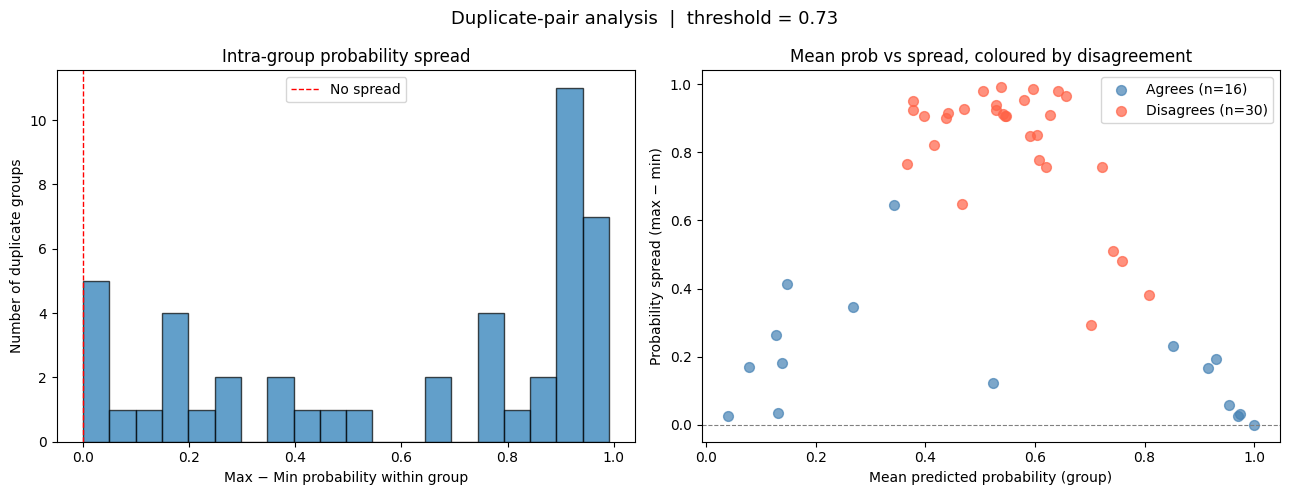

In [74]:
# ── Duplicate-pair disagreement analysis ──────────────────────────────────────
# Assumes: lgbtq_duplicates, model, tokenizer, THRESHOLD, MAX_LEN, device
# are all in scope from earlier cells.

model.eval()

def get_relevance_prob(text):
    """Run a single text through the trained LegalBERT and return P(LGBTQ+)."""
    enc = tokenizer(
        str(text).strip(),
        return_tensors='pt',
        max_length=MAX_LEN,
        truncation=True,
        padding='max_length',
    ).to(device)
    with torch.no_grad():
        logit = model(enc['input_ids'], enc['attention_mask'])
        prob = torch.sigmoid(logit).item()
    return prob

# Score every duplicate row
dup_scored['relevance_prob'] = dup_scored['text'].apply(get_relevance_prob)
dup_scored['predicted_relevant'] = (dup_scored['relevance_prob'] >= THRESHOLD).astype(int)

# ── Pair-level disagreement ────────────────────────────────────────────────────
# Group by the shared key and check if predictions differ within any group
key_cols = ['bill_number', 'year', 'state']

group_stats = (
    dup_scored
    .groupby(key_cols)
    .agg(
        n_rows             = ('predicted_relevant', 'count'),
        n_predicted_relevant = ('predicted_relevant', 'sum'),
        prob_min           = ('relevance_prob', 'min'),
        prob_max           = ('relevance_prob', 'max'),
        prob_mean          = ('relevance_prob', 'mean'),
    )
    .reset_index()
)

# A group "disagrees" if it has at least one relevant AND one non-relevant prediction
group_stats['disagreement'] = (
    (group_stats['n_predicted_relevant'] > 0) &
    (group_stats['n_predicted_relevant'] < group_stats['n_rows'])
)
group_stats['prob_spread'] = group_stats['prob_max'] - group_stats['prob_min']

n_groups      = len(group_stats)
n_disagree    = group_stats['disagreement'].sum()
n_all_relevant   = (group_stats['n_predicted_relevant'] == group_stats['n_rows']).sum()
n_none_relevant  = (group_stats['n_predicted_relevant'] == 0).sum()

print(f"Duplicate bill groups:          {n_groups}")
print(f"  All rows predicted relevant:  {n_all_relevant}  ({n_all_relevant/n_groups:.1%})")
print(f"  All rows predicted irrelevant:{n_none_relevant}  ({n_none_relevant/n_groups:.1%})")
print(f"  Disagreeing groups:           {n_disagree}  ({n_disagree/n_groups:.1%})")

# ── Show disagreeing pairs ─────────────────────────────────────────────────────
disagreeing_keys = group_stats.loc[group_stats['disagreement'], key_cols]
disagreeing_rows = dup_scored.merge(disagreeing_keys, on=key_cols)

print(f"\nRows involved in disagreeing pairs: {len(disagreeing_rows)}")
print("\nSample disagreeing pairs (sorted by bill):")
display(
    disagreeing_rows[key_cols + ['text', 'relevance_prob', 'predicted_relevant']]
    .sort_values(key_cols)
    .head(20)
)


In [77]:
# import textwrap
# from itertools import zip_longest

# COL_WIDTH = 70

# for key, group in dup_scored.groupby(key_cols):
#     print(f"\n{'='*COL_WIDTH*len(group)}")
#     print(f"bill_number={key[0]}  year={key[1]}  state={key[2]}  ({len(group)} rows)")
#     print(f"{'='*COL_WIDTH*len(group)}")

#     # Print header with relevance score for each row
#     headers = [
#         f"Row {i+1} | prob={row['relevance_prob']:.3f} | predicted={'RELEVANT' if row['predicted_relevant'] else 'NOT RELEVANT'}"
#         for i, (_, row) in enumerate(group.iterrows())
#     ]
#     print('  |  '.join(h.ljust(COL_WIDTH) for h in headers))
#     print('-' * COL_WIDTH * len(group))

#     # Wrap each row's text into lines of COL_WIDTH
#     wrapped = [textwrap.wrap(str(row['text']), width=COL_WIDTH) for _, row in group.iterrows()]

#     # Print columns side by side
#     for lines in zip_longest(*wrapped, fillvalue=''):
#         print('  |  '.join(line.ljust(COL_WIDTH) for line in lines))

# print(f"\nTotal duplicate groups: {dup_scored.groupby(key_cols).ngroups}")

Dropping rows out of the duplicate bills that scored low on relevance to LGBTQ issues:

In [79]:
# Get bill_ids that scored below threshold
irrelevant_bill_ids = set(dup_scored[dup_scored['relevance_prob'] < THRESHOLD]['bill_id'])

print(f"Bill IDs scoring below threshold: {len(irrelevant_bill_ids)}")
print(f"lgbtq_original shape before: {lgbtq_original.shape}")

# Remove those bill_ids from lgbtq_original
lgbtq_original = lgbtq_original[~lgbtq_original['bill_id'].isin(irrelevant_bill_ids)]

print(f"lgbtq_original shape after:  {lgbtq_original.shape}")


Bill IDs scoring below threshold: 66
lgbtq_original shape before: (2332, 46)
lgbtq_original shape after:  (2266, 46)


Saving the final version of matched_lgbtq_bills.csv:

In [81]:
# Save
lgbtq_original.to_csv('/content/drive/MyDrive/capstone_personal/matched_lgbtq_bills.csv', index=False)
print("Saved to matched_lgbtq_bills.csv")

Saved to matched_lgbtq_bills.csv


Saving Legal-BERT model:

In [ ]:
import os, json
from pathlib import Path

SAVE_DIR = Path("/saved_models/lgbtq_relevance_legalbert_iteration")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 1) save tokenizer
tokenizer.save_pretrained(SAVE_DIR)

# 2) save model weights + small metadata needed to rebuild the module
ckpt = {
    "model_state_dict": model.state_dict(),
    "base_model_name": MODEL_NAME,      # e.g. 'nlpaueb/legal-bert-base-uncased'
    "hidden_size": 768,
    "dropout": 0.3,
}
torch.save(ckpt, SAVE_DIR / "relevance_model_iteration.pt")

print(f"Saved relevance model to: {SAVE_DIR.resolve()}")

In [ ]:
all_preds

# Stance

In [ ]:
train_df.columns

In [ ]:
train_df['label']

In [ ]:
features = [
    'state_r_sponsorship_ratio',
    'dominant_party',
    # 'state_R_leaning',
    # 'total_yea',
    # 'total_nay',
    'percent_nay',
    'r_sponsors',
    'd_sponsors',
    'other_sponsors',
]

train_df['true_stance'] = train_df['label']
train_df['is_lgbtq'] = train_df['label_id']

# Select a subset of columns
df_subset = train_df.loc[
          train_df['is_lgbtq'] == 1,
          features + ['true_stance']
      ]

df_subset['true_stance'] = (df_subset['true_stance'] == 'harmful').astype(int)

if 'dominant_party' in df_subset.columns:
    df_subset['dominant_party'] = (df_subset['dominant_party'] == 'R').astype(int)

print(df_subset)

In [ ]:
# test version

test_df['true_stance'] = test_df['label']
test_df['is_lgbtq'] = test_df['label_id']

# Select a subset of columns
df_subset_test = test_df.loc[
          test_df['is_lgbtq'] == 1,
          features + ['true_stance']
      ]

df_subset_test['true_stance'] = (df_subset_test['true_stance'] == 'harmful').astype(int)

if 'dominant_party' in df_subset_test.columns:
    df_subset_test['dominant_party'] = (df_subset_test['dominant_party'] == 'R').astype(int)

print(df_subset_test)

In [ ]:
# fix so train are the same
# X = df_subset.drop(columns='true_stance')
# y = df_subset['true_stance']

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,          # 20% test set
#     stratify=y,             # keeps harmful/supportive proportions
#     random_state=42
# )

X_train = df_subset.drop(columns='true_stance')
y_train = df_subset['true_stance']

X_test = df_subset_test.drop(columns='true_stance')
y_test = df_subset_test['true_stance']



In [ ]:
print(df_subset.isna().sum())

In [ ]:
print(df_subset_test.isna().sum())

In [ ]:
model_2 = LogisticRegression(max_iter=500) # max_iter = 1000 originally
# , class_weight='balanced'

model_2.fit(X_train, y_train)

In [ ]:
y_pred = model_2.predict(X_test)

print('New linear stance model_2 using state, sponsor, and voting metadata:\n')
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['supportive', 'harmful']))

In [ ]:
# print('Old binary stance model using only dominant party:\n')

# y_pred_prev = np.where(df_subset['dominant_party'] == 1, 1, 0)

# y_true = df_subset['true_stance']

# print("Accuracy:", accuracy_score(y_true, y_pred_prev))
# print(classification_report(y_true, y_pred_prev, target_names=['supportive', 'harmful']))

In [ ]:
len(X_test)

In [ ]:
len(all_preds)

#Cumulative Test Accuracy Report
Results from both models hooked together

In [ ]:
# Attach predictions to dataframe
test_df['relevant_pred'] = all_preds

# Select only bills predicted as LGBTQ-relevant
df_subset_test_final = test_df.loc[
    test_df['relevant_pred'] == 1,
    features + ['true_stance']
].copy()

# Convert stance to binary target
df_subset_test_final['true_stance'] = (df_subset_test_final['true_stance'] == 'harmful').astype(int)

# Convert dominant_party if present
if 'dominant_party' in df_subset_test_final.columns:
    df_subset_test_final['dominant_party'] = (df_subset_test_final['dominant_party'] == 'R').astype(int)

print(df_subset_test_final)

In [ ]:
test_df['true_cumulative_label'] = np.where(
    test_df['is_lgbtq'] == True,
    test_df['true_stance'],
    "not applicable"
)

In [ ]:
X_test_final = df_subset_test_final.drop(columns='true_stance')
y_test_final = df_subset_test_final['true_stance']

stance_preds = model_2.predict(X_test_final)

In [ ]:
test_df['pred_cumulative_label'] = "not applicable"

# Fill in stance predictions for relevant bills
test_df.loc[test_df['relevant_pred'] == 1, 'pred_cumulative_label'] = stance_preds

test_df['pred_cumulative_label'] = test_df['pred_cumulative_label'].replace({
    1: 'harmful',
    0: 'supportive'
})

In [ ]:
print(
    test_df[['relevant_pred','pred_cumulative_label']].head(10)
)

In [ ]:
print('Combination Accuracy Assessment of relevance and stance models:\n')
print("Accuracy:", accuracy_score(test_df['true_cumulative_label'],
        test_df['pred_cumulative_label']))
print(classification_report(
        test_df['true_cumulative_label'],
        test_df['pred_cumulative_label']
    ))